In [2]:
import warnings
warnings.filterwarnings("ignore")


import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K
from collections import Counter
import tensorflow as tf
import keras_tuner as kt

df = pd.read_csv('enhanced_dataset.csv')
df.tail()

,date,year,month,day,dayofweek,is_weekend,dayofyear,month_sin,month_cos,dayofyear_sin,...,relative_humidity_2m_max__lag_7,relative_humidity_2m_max__rolling_mean_7d,relative_humidity_2m_max__rolling_std_7d,relative_humidity_2m_max__7day_trend,cloud_rain_interaction,temp_humidity_interaction,precip_cloud_interaction,cloud_volatility_7d,rain_volatility_7d,temp_seasonal_anomaly
9247,2025-04-26,2025,4,26,5,True,116,0.866025,-0.5,0.911169,...,81.0,85.142857,5.843189,9.0,0.0,330.0,0.0,23.027933,15.102065,-2.538462
9248,2025-04-27,2025,4,27,6,True,117,0.866025,-0.5,0.903946,...,91.0,85.714286,6.651172,4.0,330.0,285.6,300.0,23.483530,15.023077,-3.503846
9249,2025-04-28,2025,4,28,0,False,118,0.866025,-0.5,0.896456,...,91.0,85.571429,6.528327,-1.0,288.0,270.6,480.0,23.107410,1.521747,-3.942308
9250,2025-04-29,2025,4,29,1,False,119,0.866025,-0.5,0.888701,...,80.0,87.571429,6.679749,14.0,460.0,329.0,1200.0,22.867111,1.978576,-4.903846
9251,2025-04-30,2025,4,30,2,False,120,0.866025,-0.5,0.880683,...,84.0,89.428571,7.299706,13.0,0.0,524.4,0.0,23.229702,2.003212,-1.792308


**1- Hyperparameter tunning of the temp_max LSTM Model (option 15)**

In [ ]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf
import matplotlib.pyplot as plt


class OptimizedTemperatureMaxLSTM:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        self.df = df.copy()
        self.sequence_length = sequence_length
        self.forecast_horizon = forecast_horizon
        self.scaler_features = None
        self.scaler_targets = None
        self.model = None
        self.best_params = None
        self.study = None
        
        # Temperature target columns
        self.target_cols = [
            'temperature_2m_max (°C)'
        ]
        
    def preprocess_data(self):
        print("🧹 Preprocessing data for max temperature prediction...")
        df = self.df.copy()
        
        # Check which target columns are available
        available_targets = [col for col in self.target_cols if col in df.columns]
        if not available_targets:
            raise ValueError(f"None of the target columns {self.target_cols} found in the dataframe")
        
        self.available_targets = available_targets
        print(f"Available target columns: {available_targets}")
        
        # Handle missing values for targets
        for col in available_targets:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with any missing target values
        df = df.dropna(subset=available_targets)
        
        # Define feature columns (exclude date, weather_condition, and target columns)
        exclude_cols = ['date', 'weather_condition', 'relative_humidity_2m_max (%)', 'relative_humidity_2m_min (%)', 'temperature_2m_min (°C)'] + available_targets
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        
        # Handle missing values for features
        numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Scale features
        self.scaler_features = StandardScaler()
        df[feature_cols] = self.scaler_features.fit_transform(df[feature_cols])
        
        # Scale targets
        self.scaler_targets = StandardScaler()
        df[available_targets] = self.scaler_targets.fit_transform(df[available_targets])
        
        # Store processed data
        self.df_processed = df
        self.feature_cols = feature_cols
        
        print(f"Feature columns ({len(feature_cols)}): {feature_cols[:5]}..." if len(feature_cols) > 5 else f"Feature columns: {feature_cols}")
        print(f"Target columns: {available_targets}")
        print(f"Data shape after preprocessing: {df.shape}")
        
        return df
    
    def create_sequences(self):
        print(f"🪟 Creating sequences for Maximum temperature prediction...")
        
        X, y = [], []
        data = self.df_processed
        features = data[self.feature_cols].values
        targets = data[self.available_targets].values
        
        # Create sequences with sliding window
        for i in range(len(data) - self.sequence_length - self.forecast_horizon + 1):
            # Input sequence
            X_seq = features[i:i + self.sequence_length]
            
            # Target sequence (next forecast_horizon days)
            y_seq = targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            X.append(X_seq)
            y.append(y_seq)
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Created sequences: X={X.shape}, y={y.shape}")
        print(f"Input sequence length: {self.sequence_length}")
        print(f"Forecast horizon: {self.forecast_horizon}")
        print(f"Number of features: {X.shape[2]}")
        print(f"Number of target variables: {y.shape[2]}")
        
        return X, y
    
    def build_model_with_params(self, trial, input_shape, output_shape):
        
        # Hyperparameters to optimize
        lstm1_units = trial.suggest_int('lstm1_units', 32, 256, step=32)
        lstm2_units = trial.suggest_int('lstm2_units', 16, 128, step=16)
        lstm3_units = trial.suggest_int('lstm3_units', 8, 64, step=8)
        
        dense1_units = trial.suggest_int('dense1_units', 32, 128, step=16)
        dense2_units = trial.suggest_int('dense2_units', 16, 64, step=8)
        
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
        recurrent_dropout = trial.suggest_float('recurrent_dropout', 0.1, 0.4, step=0.1)
        l2_reg = trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)
        
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        batch_norm = trial.suggest_categorical('batch_norm', [True, False])
        
        model = Sequential()
        
        # First LSTM layer
        model.add(LSTM(lstm1_units, return_sequences=True, input_shape=input_shape,
                      kernel_regularizer=l2(l2_reg), 
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        # Second LSTM layer
        model.add(LSTM(lstm2_units, return_sequences=True,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        # Third LSTM layer
        model.add(LSTM(lstm3_units, return_sequences=False,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(Dropout(dropout_rate + 0.1))
        
        # Dense layers
        model.add(Dense(dense1_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense2_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate))
        
        # Output layer
        model.add(Dense(output_shape[0] * output_shape[1], activation='linear'))
        
        # Reshape to (forecast_horizon, num_target_variables)
        model.add(tf.keras.layers.Reshape(output_shape))
        
        # Compile model
        model.compile(
            optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def objective(self, trial):
        
        try:
            # Create sequences
            X, y = self.create_sequences()
            
            if len(X) == 0:
                return float('inf')
            
            # Train-validation split
            X_train, X_val, y_train, y_val = train_test_split(
                X, y, test_size=0.2, random_state=42, shuffle=True
            )
            
            # Build model with trial parameters
            input_shape = (self.sequence_length, X.shape[2])
            output_shape = (self.forecast_horizon, len(self.available_targets))
            
            model = self.build_model_with_params(trial, input_shape, output_shape)
            
            # Training parameters
            batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
            
            # Callbacks
            callbacks = [
                EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
            ]
            
            # Train model
            history = model.fit(
                X_train, y_train,
                epochs=50,  # Reduced for faster optimization
                batch_size=batch_size,
                validation_data=(X_val, y_val),
                callbacks=callbacks,
                verbose=0
            )
            
            # Get best validation loss
            best_val_loss = min(history.history['val_loss'])
            
            # Clean up to free memory
            del model
            tf.keras.backend.clear_session()
            
            return best_val_loss
            
        except Exception as e:
            print(f"Trial failed with error: {e}")
            return float('inf')
    
    def optimize_hyperparameters(self, n_trials=20, timeout=None):
        
        print("\n" + "="*70)
        print("🔧 HYPERPARAMETER OPTIMIZATION WITH OPTUNA")
        print("="*70)
        
        # Create study
        self.study = optuna.create_study(direction='minimize', 
                                        study_name='temperature_lstm_optimization')
        
        print(f"Starting optimization with {n_trials} trials...")
        if timeout:
            print(f"Timeout set to {timeout} seconds")
        
        # Optimize
        self.study.optimize(self.objective, n_trials=n_trials, timeout=timeout)
        
        # Get best parameters
        self.best_params = self.study.best_params
        
        print("\n🏆 OPTIMIZATION COMPLETED!")
        print("="*50)
        print(f"Best validation loss: {self.study.best_value:.6f}")
        print(f"Number of trials: {len(self.study.trials)}")
        
        print(f"\n🎯 BEST HYPERPARAMETERS:")
        print("-" * 40)
        for key, value in self.best_params.items():
            print(f"{key:20s}: {value}")
        
        return self.best_params
    
    def build_best_model(self, input_shape, output_shape):
        """Build model with best parameters found by Optuna"""
        if self.best_params is None:
            raise ValueError("No optimization performed yet. Run optimize_hyperparameters() first.")
        
        model = Sequential()
        
        # Use best parameters
        lstm1_units = self.best_params['lstm1_units']
        lstm2_units = self.best_params['lstm2_units']
        lstm3_units = self.best_params['lstm3_units']
        dense1_units = self.best_params['dense1_units']
        dense2_units = self.best_params['dense2_units']
        dropout_rate = self.best_params['dropout_rate']
        recurrent_dropout = self.best_params['recurrent_dropout']
        l2_reg = self.best_params['l2_reg']
        learning_rate = self.best_params['learning_rate']
        batch_norm = self.best_params['batch_norm']
        
        # Build architecture
        model.add(LSTM(lstm1_units, return_sequences=True, input_shape=input_shape,
                      kernel_regularizer=l2(l2_reg), 
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(LSTM(lstm2_units, return_sequences=True,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(LSTM(lstm3_units, return_sequences=False,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense1_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense2_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate))
        
        model.add(Dense(output_shape[0] * output_shape[1], activation='linear'))
        model.add(tf.keras.layers.Reshape(output_shape))
        
        # Compile with best parameters
        model.compile(
            optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def train_optimized_model(self, validation_split=0.2, epochs=200):
        
        print("\n" + "="*70)
        print("TRAINING OPTIMIZED TEMPERATURE MAX LSTM MODEL")
        print("="*70)
        
        if self.best_params is None:
            raise ValueError("No optimization performed yet. Run optimize_hyperparameters() first.")
        
        # Create sequences
        X, y = self.create_sequences()
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build optimized model
        input_shape = (self.sequence_length, X.shape[2])
        output_shape = (self.forecast_horizon, len(self.available_targets))
        
        self.model = self.build_best_model(input_shape, output_shape)
        
        print(f"\nOptimized model architecture:")
        self.model.summary()
        
        # Use best batch size
        batch_size = self.best_params.get('batch_size', 32)
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print(f"\nTraining optimized model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print(f"\nEvaluating optimized model...")
        y_pred = self.model.predict(X_test, verbose=0)
        
        return self.evaluate_model(y_test, y_pred, history)
    
    def evaluate_model(self, y_true, y_pred, history):
        print("\n" + "="*70)
        print("OPTIMIZED TEMPERATURE MAX LSTM RESULTS")
        print("="*70)
        
        # Inverse transform predictions and true values to original scale
        y_true_original = np.zeros_like(y_true)
        y_pred_original = np.zeros_like(y_pred)
        
        for day in range(self.forecast_horizon):
            y_true_original[:, day, :] = self.scaler_targets.inverse_transform(y_true[:, day, :])
            y_pred_original[:, day, :] = self.scaler_targets.inverse_transform(y_pred[:, day, :])
        
        # Calculate metrics for each target variable and forecast day
        results = {}
        
        for i, target_name in enumerate(self.available_targets):
            print(f"\n🌡️ {target_name}:")
            print("-" * 50)
            
            target_results = {
                'mae': [],
                'rmse': [],
                'r2': [],
                'mape': []
            }
            
            for day in range(self.forecast_horizon):
                y_true_day = y_true_original[:, day, i]
                y_pred_day = y_pred_original[:, day, i]
                
                mae = mean_absolute_error(y_true_day, y_pred_day)
                rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
                r2 = r2_score(y_true_day, y_pred_day)
                
                # Calculate MAPE (Mean Absolute Percentage Error)
                mape = np.mean(np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))) * 100
                
                target_results['mae'].append(mae)
                target_results['rmse'].append(rmse)
                target_results['r2'].append(r2)
                target_results['mape'].append(mape)
                
                print(f"  Day {day+1}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}, MAPE={mape:.2f}%")
            
            # Calculate averages
            avg_mae = np.mean(target_results['mae'])
            avg_rmse = np.mean(target_results['rmse'])
            avg_r2 = np.mean(target_results['r2'])
            avg_mape = np.mean(target_results['mape'])
            
            target_results['avg_mae'] = avg_mae
            target_results['avg_rmse'] = avg_rmse
            target_results['avg_r2'] = avg_r2
            target_results['avg_mape'] = avg_mape
            
            print(f"  Average: MAE={avg_mae:.3f}, RMSE={avg_rmse:.3f}, R²={avg_r2:.3f}, MAPE={avg_mape:.2f}%")
            
            results[target_name] = target_results
        
        # Overall performance summary
        print(f"\n📊 OVERALL PERFORMANCE SUMMARY:")
        print("="*50)
        
        all_maes = [results[target]['avg_mae'] for target in self.available_targets]
        all_rmses = [results[target]['avg_rmse'] for target in self.available_targets]
        all_r2s = [results[target]['avg_r2'] for target in self.available_targets]
        all_mapes = [results[target]['avg_mape'] for target in self.available_targets]
        
        print(f"Overall Average MAE: {np.mean(all_maes):.3f}")
        print(f"Overall Average RMSE: {np.mean(all_rmses):.3f}")
        print(f"Overall Average R²: {np.mean(all_r2s):.3f}")
        print(f"Overall Average MAPE: {np.mean(all_mapes):.2f}%")
        
        # Optimization summary
        if self.best_params:
            print(f"\n🔧 OPTIMIZATION SUMMARY:")
            print("-" * 40)
            print(f"Best validation loss: {self.study.best_value:.6f}")
            print(f"Number of trials completed: {len(self.study.trials)}")
            print(f"Best LSTM architecture: {self.best_params['lstm1_units']}-{self.best_params['lstm2_units']}-{self.best_params['lstm3_units']}")
            print(f"Best Dense architecture: {self.best_params['dense1_units']}-{self.best_params['dense2_units']}")
            print(f"Best learning rate: {self.best_params['learning_rate']:.6f}")
            print(f"Best dropout rate: {self.best_params['dropout_rate']:.3f}")
        
        return results, history, y_true_original, y_pred_original
    
    def predict_future(self, recent_data, days_ahead=None):
        if days_ahead is None:
            days_ahead = self.forecast_horizon
        
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_features.transform(recent_data[self.feature_cols])
        else:
            recent_scaled = recent_data
        
        # Use the last sequence_length days as input
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        
        # Make prediction
        prediction_scaled = self.model.predict(input_seq, verbose=0)
        
        # Inverse transform to original scale
        prediction_original = np.zeros_like(prediction_scaled)
        for day in range(self.forecast_horizon):
            prediction_original[0, day, :] = self.scaler_targets.inverse_transform(
                prediction_scaled[0, day, :].reshape(1, -1)
            )
        
        # Create results dictionary
        results = {}
        for i, target_name in enumerate(self.available_targets):
            results[target_name] = prediction_original[0, :days_ahead, i]
        
        return results
    
    def plot_training_history(self, history):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss
        ax1.plot(history.history['loss'], label='Training Loss')
        ax1.plot(history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Optimized Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        
        # MAE
        ax2.plot(history.history['mae'], label='Training MAE')
        ax2.plot(history.history['val_mae'], label='Validation MAE')
        ax2.set_title('Optimized Model MAE')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
    
    def plot_optimization_history(self):
        
        if self.study is None:
            print("No optimization study available to plot.")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Optimization history
        values = [trial.value for trial in self.study.trials if trial.value is not None]
        ax1.plot(values)
        ax1.set_title('Optimization History')
        ax1.set_xlabel('Trial')
        ax1.set_ylabel('Validation Loss')
        ax1.grid(True)
        
        # Parameter importance (if available)
        try:
            importance = optuna.importance.get_param_importances(self.study)
            params = list(importance.keys())
            importances = list(importance.values())
            
            ax2.barh(params, importances)
            ax2.set_title('Parameter Importance')
            ax2.set_xlabel('Importance')
        except:
            ax2.text(0.5, 0.5, 'Parameter importance\nnot available', 
                    ha='center', va='center', transform=ax2.transAxes)
        
        plt.tight_layout()
        plt.show()

🌡️ OPTUNA-OPTIMIZED MAXIMUM TEMPERATURE LSTM FORECASTING
🧹 Preprocessing data for max temperature prediction...
Available target columns: ['temperature_2m_max (°C)']


[I 2025-06-28 12:14:33,779] A new study created in memory with name: temperature_lstm_optimization


Feature columns (151): ['year', 'month', 'day', 'dayofweek', 'is_weekend']...
Target columns: ['temperature_2m_max (°C)']
Data shape after preprocessing: (9252, 157)

🔧 HYPERPARAMETER OPTIMIZATION WITH OPTUNA
Starting optimization with 15 trials...
Timeout set to 3600 seconds
🪟 Creating sequences for Maximum temperature prediction...
Created sequences: X=(9240, 10, 151), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 151
Number of target variables: 1



[I 2025-06-28 12:16:56,541] Trial 0 finished with value: 0.213450625538826 and parameters: {'lstm1_units': 64, 'lstm2_units': 48, 'lstm3_units': 8, 'dense1_units': 80, 'dense2_units': 24, 'dropout_rate': 0.2, 'recurrent_dropout': 0.2, 'l2_reg': 0.007575444278454939, 'learning_rate': 0.00016146149690824443, 'batch_norm': False, 'batch_size': 32}. Best is trial 0 with value: 0.213450625538826.


🪟 Creating sequences for Maximum temperature prediction...
Created sequences: X=(9240, 10, 151), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 151
Number of target variables: 1


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 256)        │       417,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 48)             │        33,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 48)             │         6,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           147 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 661,507 (2.52 MB)

 Trainable params: 661,507 (2.52 MB)

 Non-trainable params: 0 (0.00 B)


Training optimized model...
Epoch 1/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.5252 - mae: 0.5659 - val_loss: 0.2280 - val_mae: 0.3626 - learning_rate: 0.0015
Epoch 2/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.3088 - mae: 0.4272 - val_loss: 0.2131 - val_mae: 0.3536 - learning_rate: 0.0015
Epoch 3/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - loss: 0.2805 - mae: 0.4028 - val_loss: 0.2397 - val_mae: 0.3709 - learning_rate: 0.0015
Epoch 4/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.2466 - mae: 0.3753 - val_loss: 0.1849 - val_mae: 0.3133 - learning_rate: 0.0015
Epoch 5/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.2377 - mae: 0.3662 - val_loss: 0.1881 - val_mae: 0.3167 - learning_rate: 0.0015
Epoch 6/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.2217 - mae: 0.3550 - val_loss: 0.1831 - val_mae: 0.3109 - learning_rate: 0.0015
Epoch 7/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.2023 - mae: 0.3360 - val_loss: 0.1839 - va

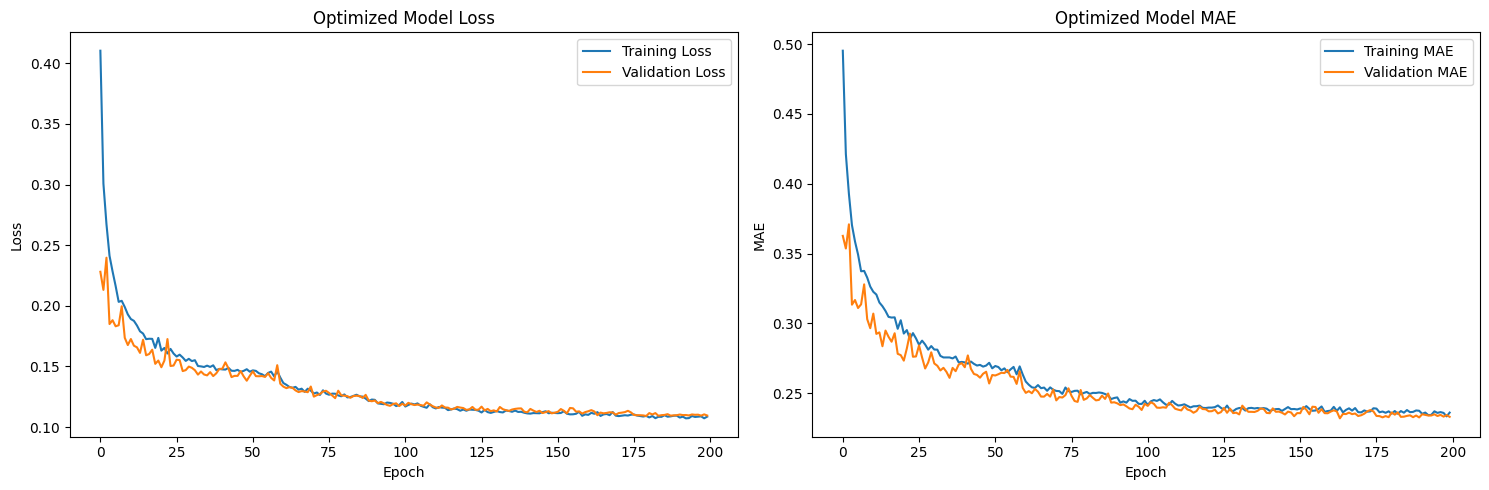

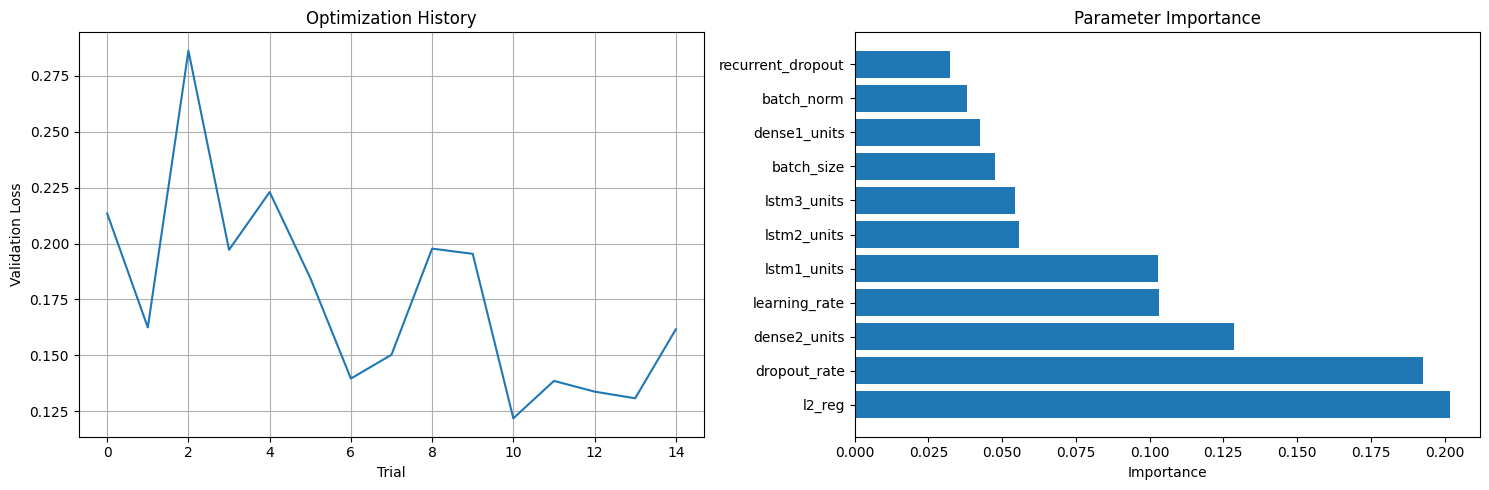

In [4]:
def run_optimized_temperature_forecasting(df, n_trials=20, timeout=None):
    
    print("🌡️ OPTUNA-OPTIMIZED MAXIMUM TEMPERATURE LSTM FORECASTING")
    print("=" * 70)
    
    # Initialize model
    model = OptimizedTemperatureMaxLSTM(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data()
    
    # Optimize hyperparameters
    best_params = model.optimize_hyperparameters(n_trials=n_trials, timeout=timeout)
    
    # Train optimized model
    results, history, y_true, y_pred = model.train_optimized_model(
        validation_split=0.2, 
        epochs=200
    )
    
    # Plot results
    model.plot_training_history(history)
    model.plot_optimization_history()
    
    return model, results, history, y_true, y_pred, best_params

# Usage example:
model, results, history, y_true, y_pred, best_params = run_optimized_temperature_forecasting(
    df, n_trials=15, timeout=3600)


🔮 Making 3-day Maximum temperature forecast...
--------------------------------------------------
📅 3-Day Maximum Temperature Forecast:
  Thursday   (2025-05-01):
     🌡️ temperature_2m_max (°C): 28.32
  Friday     (2025-05-02):
     🌡️ temperature_2m_max (°C): 28.44
  Saturday   (2025-05-03):
     🌡️ temperature_2m_max (°C): 28.38


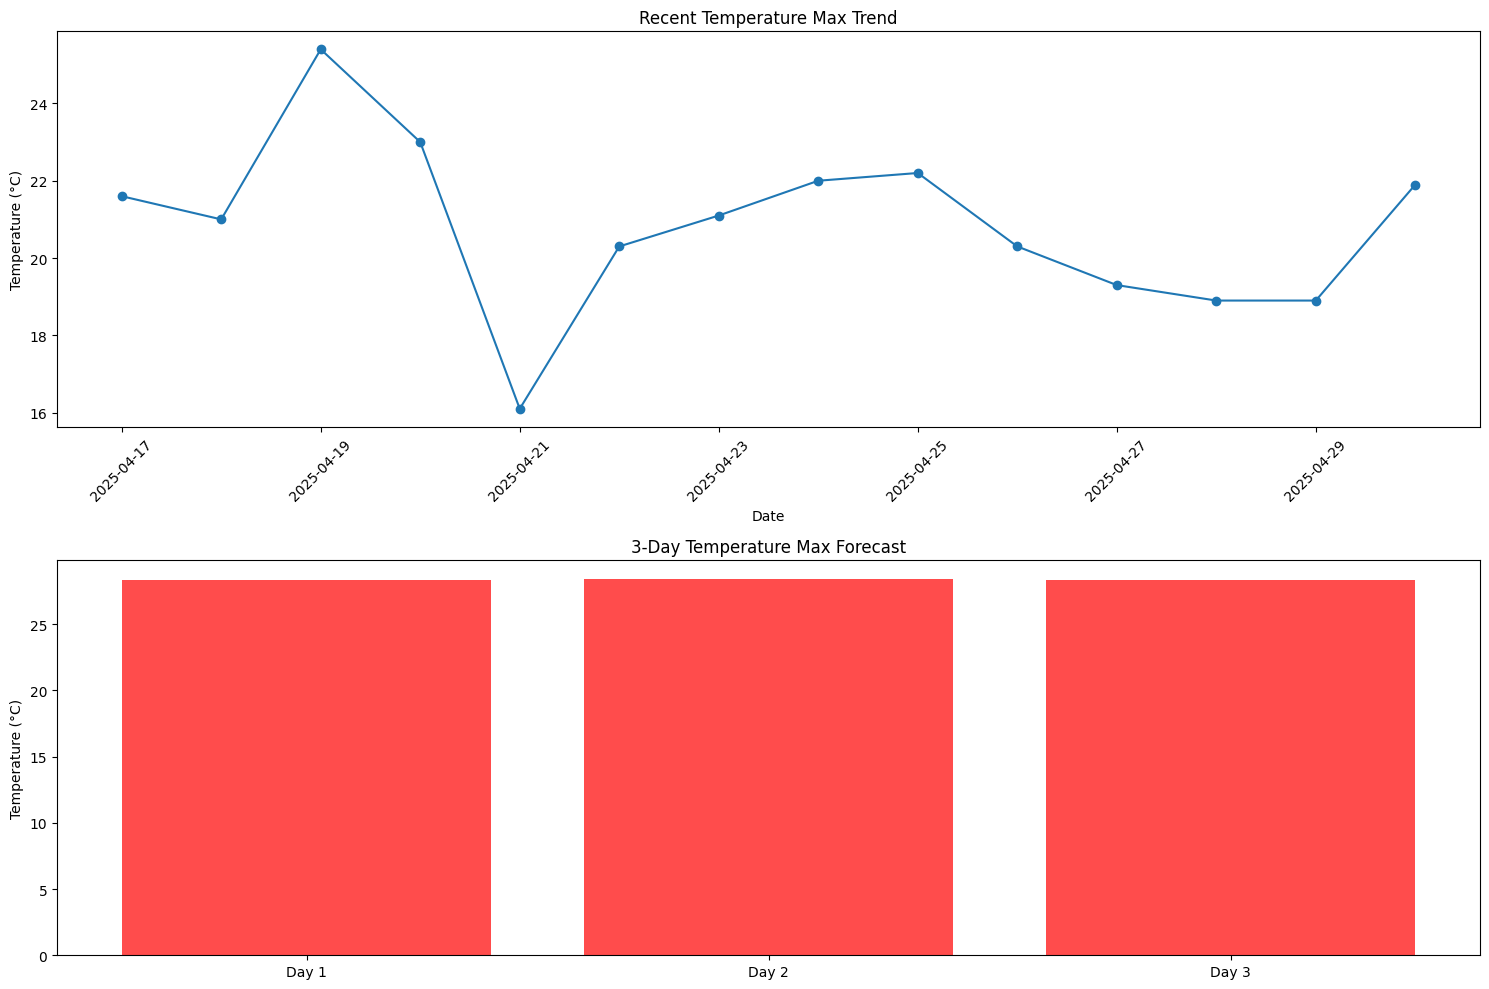

In [6]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations for min temperature only"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    import pandas as pd
    import numpy as np
    
    print("\n🔮 Making 3-day Maximum temperature forecast...")
    print("-" * 50)
    
    # Get only the features used during training
    feature_cols = model.feature_cols

    # Pull only the last `sequence_length` rows
    recent_data = df[feature_cols].tail(model.sequence_length).copy()

    # Ensure numeric and same dtype
    recent_data = recent_data.apply(pd.to_numeric, errors='coerce').dropna()

    # If any rows dropped, re-pad from the top
    if len(recent_data) < model.sequence_length:
        padding_needed = model.sequence_length - len(recent_data)
        padding = np.zeros((padding_needed, len(feature_cols)))
        recent_data = np.vstack([padding, recent_data.values])
    else:
        recent_data = recent_data.values

    # Final shape must be (1, sequence_length, num_features)
    recent_data = recent_data.reshape(1, model.sequence_length, len(feature_cols)).astype(np.float32)

    try:
        # Get temperature/humidity predictions
        temp_humidity_results = model.predict_future(recent_data)
        
        # Get next 3 days
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        print("📅 3-Day Maximum Temperature Forecast:")
        for i, (day, date) in enumerate(days_and_dates):
            print(f"  {day:10} ({date}):")
            for target_name in model.available_targets:
                value = temp_humidity_results[target_name][i]
                print(f"     🌡️ {target_name}: {value:.2f}")
        
        # Visualization
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot recent temperature trends
        if 'temperature_2m_max (°C)' in df.columns:
            recent_temp = df[['date', 'temperature_2m_max (°C)']].tail(14)
            recent_temp['date'] = pd.to_datetime(recent_temp['date'])
            axes[0].plot(recent_temp['date'], recent_temp['temperature_2m_max (°C)'], 'o-')
            axes[0].set_title('Recent Temperature Max Trend')
            axes[0].set_xlabel('Date')
            axes[0].set_ylabel('Temperature (°C)')
            axes[0].tick_params(axis='x', rotation=45)
        
        # Plot forecast temperature
        forecast_days = [f"Day {i+1}" for i in range(3)]
        if 'temperature_2m_max (°C)' in temp_humidity_results:
            temp_forecast = temp_humidity_results['temperature_2m_max (°C)']
            axes[1].bar(forecast_days, temp_forecast, color='red', alpha=0.7)
            axes[1].set_title('3-Day Temperature Max Forecast')
            axes[1].set_ylabel('Temperature (°C)')
        
        plt.tight_layout()
        plt.show()
        
        return temp_humidity_results
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None


# Usage example:

predictions = make_predictions_and_visualize(model, df)

🌡️ MAXIMUM TEMPERATURE PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------

🌡️  temperature_2m_max (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      35.00 |      35.54 |       0.54 |       1.5%
    2 |      35.50 |      35.73 |       0.23 |       0.6%
    3 |      37.80 |      35.39 |       2.41 |       6.4%
------------------------------------------------------------
Sequence MAE: 1.059

📅 Test Sequence 2:
------------------------------------------------------------

🌡️  temperature_2m_max (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      27.00 |      29.22 |       2.22 |       8.2%
    2 |      29.90 |      29.34 |       0.56 |       1.9%
    3 |      33.70 |      29.24 |       4.46 |      

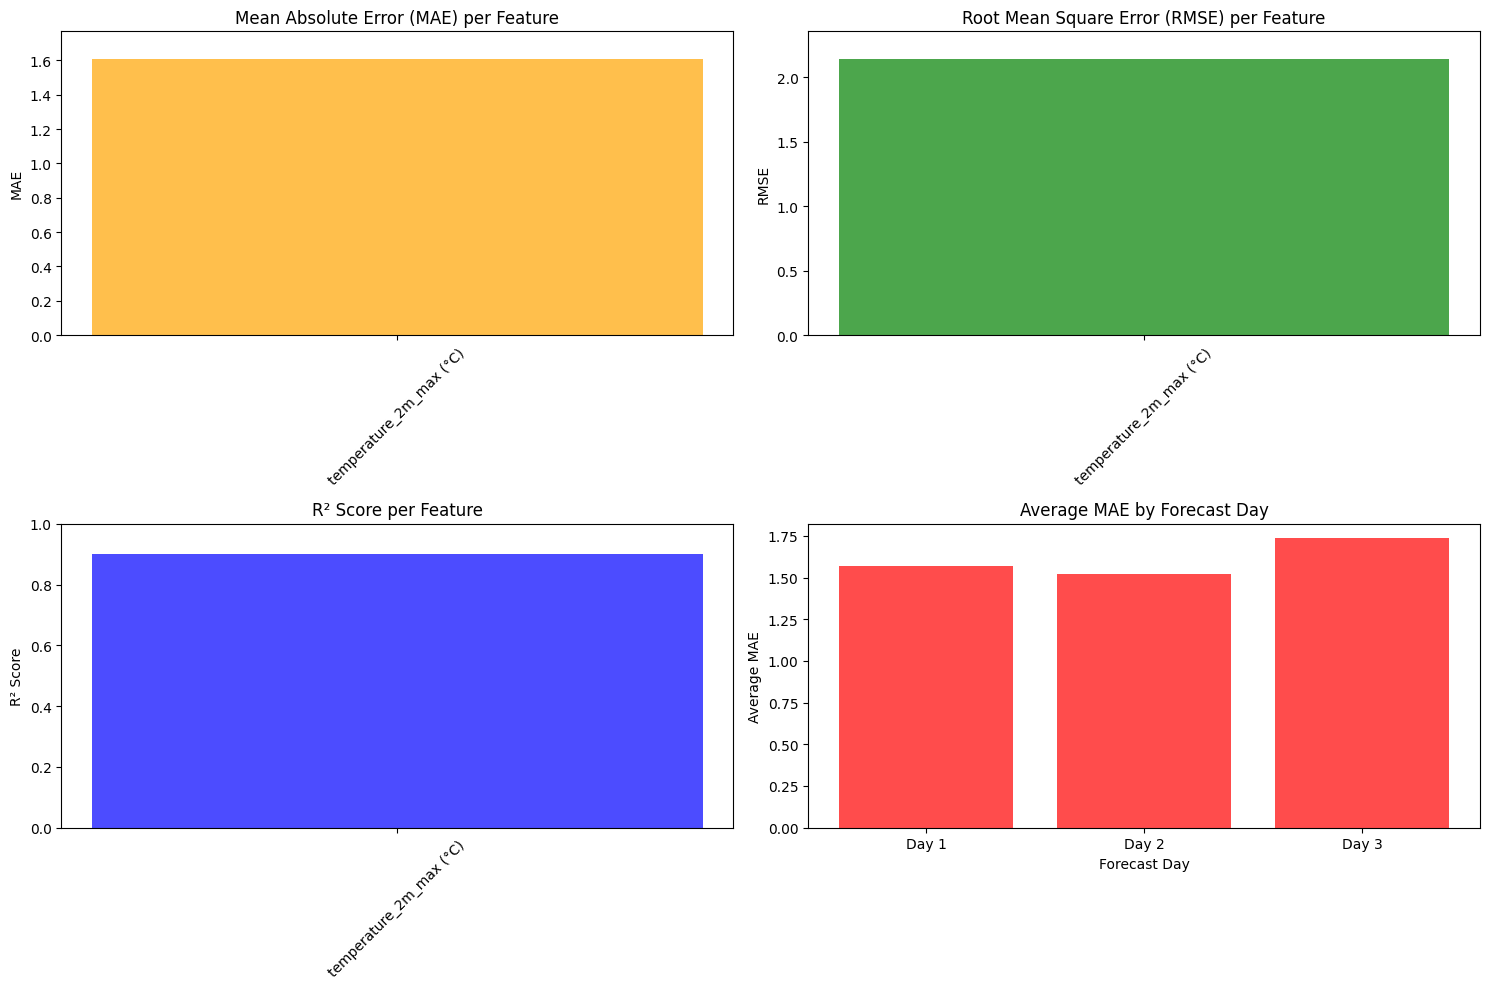


🏆 PERFORMANCE SUMMARY:
Best performing feature: temperature_2m_max (°C) (MAE: 1.608)
Worst performing feature: temperature_2m_max (°C) (MAE: 1.608)
Overall average MAE: 1.608
Overall average RMSE: 2.142
Overall average R²: 0.900


In [7]:
def show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=5
):
    """Display temperature min regression predictions only."""
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print("🌡️ MAXIMUM TEMPERATURE PREDICTIONS")
    print("=" * 60)

    sample_size = min(num_samples, len(y_true))

    # Get feature names from the model
    feature_names = model.available_targets if hasattr(model, 'available_targets') else [f"Feature {i}" for i in range(y_true.shape[2])]

    # Display sample predictions
    for i in range(sample_size):
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)

        # Create a nice table format for each feature
        for f, feature_name in enumerate(feature_names):
            print(f"\n🌡️  {feature_name}:")
            print("-" * 40)
            print(f"{'Day':>5} | {'Actual':>10} | {'Predicted':>10} | {'Error':>10} | {'% Error':>10}")
            print("-" * 60)

            mae_sequence = 0
            for day in range(model.forecast_horizon):
                actual = y_true[i, day, f]
                predicted = y_pred[i, day, f]
                error = abs(actual - predicted)
                percent_error = (error / (abs(actual) + 1e-8)) * 100
                mae_sequence += error

                print(f"{day+1:>5} | {actual:>10.2f} | {predicted:>10.2f} | {error:>10.2f} | {percent_error:>9.1f}%")

            mae_sequence /= model.forecast_horizon
            print("-" * 60)
            print(f"Sequence MAE: {mae_sequence:.3f}")

    # Overall statistics for temperature and humidity
    print(f"\n📊 OVERALL REGRESSION STATISTICS:")
    print("=" * 50)

    num_features = y_true.shape[2]

    for f, feature_name in enumerate(feature_names):
        print(f"\n🌡️  {feature_name}:")
        print("-" * 30)
        
        # Calculate metrics for this feature
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
        r2 = r2_score(y_true_flat, y_pred_flat)
        mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
        
        print(f"  MAE:  {mae:.3f}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")
        print(f"  MAPE: {mape:.2f}%")
        
        # Per-day accuracy for this feature
        print(f"\n  📈 Daily Performance:")
        for day in range(model.forecast_horizon):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae = mean_absolute_error(day_true, day_pred)
            day_rmse = np.sqrt(mean_squared_error(day_true, day_pred))
            day_r2 = r2_score(day_true, day_pred)
            print(f"    Day {day+1}: MAE={day_mae:.3f}, RMSE={day_rmse:.3f}, R²={day_r2:.3f}")

    # Create visualization
    print(f"\n📈 CREATING PERFORMANCE VISUALIZATION...")
    
    # Calculate metrics for plotting
    maes = []
    rmses = []
    r2s = []
    
    for f in range(num_features):
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        maes.append(mean_absolute_error(y_true_flat, y_pred_flat))
        rmses.append(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))
        r2s.append(r2_score(y_true_flat, y_pred_flat))

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # MAE plot
    axes[0, 0].bar(feature_names, maes, color='orange', alpha=0.7)
    axes[0, 0].set_title("Mean Absolute Error (MAE) per Feature")
    axes[0, 0].set_ylabel("MAE")
    axes[0, 0].set_ylim(0, max(maes) * 1.1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE plot
    axes[0, 1].bar(feature_names, rmses, color='green', alpha=0.7)
    axes[0, 1].set_title("Root Mean Square Error (RMSE) per Feature")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].set_ylim(0, max(rmses) * 1.1)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # R² plot
    axes[1, 0].bar(feature_names, r2s, color='blue', alpha=0.7)
    axes[1, 0].set_title("R² Score per Feature")
    axes[1, 0].set_ylabel("R² Score")
    axes[1, 0].set_ylim(0, max(1.0, max(r2s) * 1.1))
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Daily performance comparison
    day_labels = [f"Day {i+1}" for i in range(model.forecast_horizon)]
    daily_maes = []
    
    for day in range(model.forecast_horizon):
        day_mae_all_features = []
        for f in range(num_features):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae_all_features.append(mean_absolute_error(day_true, day_pred))
        daily_maes.append(np.mean(day_mae_all_features))
    
    axes[1, 1].bar(day_labels, daily_maes, color='red', alpha=0.7)
    axes[1, 1].set_title("Average MAE by Forecast Day")
    axes[1, 1].set_ylabel("Average MAE")
    axes[1, 1].set_xlabel("Forecast Day")
    
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n🏆 PERFORMANCE SUMMARY:")
    print("=" * 30)
    print(f"Best performing feature: {feature_names[np.argmin(maes)]} (MAE: {min(maes):.3f})")
    print(f"Worst performing feature: {feature_names[np.argmax(maes)]} (MAE: {max(maes):.3f})")
    print(f"Overall average MAE: {np.mean(maes):.3f}")
    print(f"Overall average RMSE: {np.mean(rmses):.3f}")
    print(f"Overall average R²: {np.mean(r2s):.3f}")


# Usage example - replace your original function call with this:
show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=3
)

In [9]:
def save_lstm_model(model, model_name="TemperatureMaxLSTM", save_dir="saved_models"):
    import os
    import json
    import pickle
    from datetime import datetime
    import joblib

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)

    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)

    try:
        # 1. Save the Keras model
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print("✅ Keras model saved.")

        # 2. Save scalers
        joblib.dump(model.scaler_features, f"{model_folder}/scaler_features.pkl")
        joblib.dump(model.scaler_targets, f"{model_folder}/scaler_targets.pkl")
        print("✅ Scalers saved.")

        # 3. Save config
        config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'available_targets': model.available_targets,
            'feature_columns': model.feature_cols,
            'timestamp': timestamp,
            'model_type': 'TemperatureMaxLSTM',
            'framework': 'TensorFlow/Keras'
        }
        with open(f"{model_folder}/model_config.json", 'w') as f:
            json.dump(config, f, indent=4)
        print("✅ Model configuration saved.")

        # 4. Save model object (without keras model to avoid issues)
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)
        with open(f"{model_folder}/full_model.pkl", 'wb') as f:
            pickle.dump(model_copy, f)
        print("✅ Full model object saved.")

        return model_folder

    except Exception as e:
        print(f"❌ Error saving model: {e}")
        return None



def load_lstm_model(model_folder):
    import os
    import json
    import pickle
    import joblib
    from tensorflow.keras.models import load_model

    try:
        print(f"📂 Loading model from: {model_folder}")

        # Load keras model
        keras_model = load_model(f"{model_folder}/keras_model.keras")

        # Load scalers
        scaler_features = joblib.load(f"{model_folder}/scaler_features.pkl")
        scaler_targets = joblib.load(f"{model_folder}/scaler_targets.pkl")

        # Load config
        with open(f"{model_folder}/model_config.json", 'r') as f:
            config = json.load(f)

        # Load full model dict
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)

        # Create empty model object
        model = TemperatureMinLSTM(pd.DataFrame(), config['sequence_length'], config['forecast_horizon'])
        model.model = keras_model
        model.scaler_features = scaler_features
        model.scaler_targets = scaler_targets

        # Restore other attributes
        for key, value in model_dict.items():
            setattr(model, key, value)

        print(f"✅ Model '{config['model_name']}' successfully loaded!")
        return model

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None


model_folder = save_lstm_model(model, model_name="BestMaximumTemperatureLSTM_Model1")

💾 Saving 'BestMaximumTemperatureLSTM_Model1' to: saved_models/BestMaximumTemperatureLSTM_Model1_20250628_133733
✅ Keras model saved.
✅ Scalers saved.
✅ Model configuration saved.
✅ Full model object saved.


**2- Hyperparameter tunning of the temp_min LSTM Model (option 15)**

**3- Hyperparameter tunning of the humidity_max LSTM Model (option 15)**

**4- Hyperparameter tunning of the humidity_min LSTM Model (option 15)**

**5- Hyperparameter tunning of the Weather condition LSTM Model (Model 3)**

In [ ]:
class ImprovedSlidingWindowModel:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        
        self.df = df.copy()
        self.forecast_horizon = forecast_horizon
        self.sequence_length = sequence_length
        self.scaler_X = None
        self.label_encoder = None
        self.model = None
        self.class_weights = None
        self.tuner = None
        self.best_hps = None
        
        # Improved thresholds for better balance
        self.minority_threshold = 0.08   # Very rare classes
        self.balanced_threshold = 0.20   # Medium frequency classes
        # Above 20% = majority classes
        
    def preprocess_data(self, target_col='weather_condition'):
        
        print("🧹 Enhanced preprocessing...")
        df = self.df.copy()
        
        # Handle missing values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col != target_col:
                df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
                df[col] = df[col].interpolate(method='linear')
                df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with missing target
        df = df.dropna(subset=[target_col])
        # 🔄 Merge specific weather classes
        df[target_col] = df[target_col].replace({
            'Mainly Clear 🌤': 'Partly Clear 🌤/⛅',
            'Partly Cloudy ⛅': 'Partly Clear 🌤/⛅'
        })
        
        # Three-tier class analysis
        class_counts = df[target_col].value_counts()
        total_samples = len(df)
        print(f"Original class distribution:\n{class_counts}")
        print(f"Class percentages:\n{(class_counts/total_samples*100).round(2)}")
        
        # Categorize classes into three tiers
        self.minority_classes = []    # < 8%
        self.balanced_classes = []    # 8% - 20%  
        self.majority_classes = []    # > 20%
        
        for class_name, count in class_counts.items():
            percentage = count / total_samples
            if percentage < self.minority_threshold:
                self.minority_classes.append(class_name)
            elif percentage < self.balanced_threshold:
                self.balanced_classes.append(class_name)
            else:
                self.majority_classes.append(class_name)
        
        print(f"\nMinority classes (<{self.minority_threshold*100}%): {self.minority_classes}")
        print(f"Balanced classes ({self.minority_threshold*100}%-{self.balanced_threshold*100}%): {self.balanced_classes}")
        print(f"Majority classes (>{self.balanced_threshold*100}%): {self.majority_classes}")
        
        # Encode target
        self.label_encoder = LabelEncoder()
        df[target_col + '_encoded'] = self.label_encoder.fit_transform(df[target_col])
        
        # Feature engineering
        feature_cols = [col for col in df.columns if col not in ['date', target_col, target_col + '_encoded']]
        
        # Scale features
        self.scaler_X = StandardScaler()
        df[feature_cols] = self.scaler_X.fit_transform(df[feature_cols])
        
        # Calculate class weights
        unique_classes = np.unique(df[target_col + '_encoded'])
        self.class_weights = compute_class_weight('balanced', classes=unique_classes, y=df[target_col + '_encoded'])
        self.class_weight_dict = dict(zip(unique_classes, self.class_weights))
        
        # Store processed data
        self.df = df
        self.feature_cols = feature_cols
        self.target_col = target_col + '_encoded'
        self.original_target_col = target_col
        
        return df

    def create_improved_sliding_windows(self):
        
        print(f"\n🪟 Creating improved sliding windows with controlled rebalancing...")
        
        X, y = [], []
        data = self.df
        features = data[self.feature_cols].values
        target = data[self.target_col].values
        
        # Get class IDs for each tier
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        balanced_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.balanced_classes 
                             if cls in self.label_encoder.classes_]
        majority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.majority_classes 
                             if cls in self.label_encoder.classes_]
        
        print(f"Minority class IDs: {minority_class_ids}")
        print(f"Balanced class IDs: {balanced_class_ids}")
        print(f"Majority class IDs: {majority_class_ids}")
        
        # Strategy 1: Intensive sampling for minority classes
        minority_windows = 0
        print("Creating intensive windows for minority classes...")
        
        for i in range(len(target)):
            if target[i] in minority_class_ids:
                # Create 7 overlapping windows around each minority event
                for offset in range(-3, 4):
                    start_idx = max(0, i - self.sequence_length + offset)
                    end_idx = start_idx + self.sequence_length + self.forecast_horizon
                    
                    if end_idx <= len(data):
                        X_seq = features[start_idx:start_idx + self.sequence_length]
                        y_seq = target[start_idx + self.sequence_length:end_idx]
                        
                        if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                            X.append(X_seq)
                            y.append(y_seq)
                            minority_windows += 1
        
        # Strategy 2: Moderate sampling for balanced classes
        balanced_windows = 0
        print("Creating moderate windows for balanced classes...")
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, 2):
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Check if sequence contains balanced classes
            if any(cls_id in balanced_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                balanced_windows += 1
        
        # Strategy 3: Controlled sampling for majority classes
        majority_windows = 0
        print("Creating controlled windows for majority classes...")
        
        # Calculate target number of majority windows (don't let them dominate)
        target_majority_windows = max(minority_windows * 1.5, balanced_windows * 0.8)
        
        majority_stride = max(3, int((len(data) - self.sequence_length - self.forecast_horizon) / target_majority_windows))
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, majority_stride):
            if majority_windows >= target_majority_windows:
                break
                
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Only add if it's primarily majority class and we haven't hit our limit
            if all(cls_id in majority_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                majority_windows += 1
        
        # Strategy 4: Add transitional windows (sequences that show class changes)
        transition_windows = 0
        print("Adding transitional windows...")
        
        for i in range(len(target) - self.forecast_horizon):
            current_class = target[i]
            future_classes = target[i+1:i+self.forecast_horizon+1]
            
            # Look for transitions from/to minority classes
            if (current_class in minority_class_ids or any(cls in minority_class_ids for cls in future_classes)):
                start_idx = max(0, i - self.sequence_length + 1)
                if start_idx + self.sequence_length + self.forecast_horizon <= len(data):
                    X_seq = features[start_idx:start_idx + self.sequence_length]
                    y_seq = target[start_idx + self.sequence_length:start_idx + self.sequence_length + self.forecast_horizon]
                    
                    if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                        X.append(X_seq)
                        y.append(y_seq)
                        transition_windows += 1
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"\nWindow creation results:")
        print(f"Minority class windows: {minority_windows}")
        print(f"Balanced class windows: {balanced_windows}")
        print(f"Majority class windows: {majority_windows}")
        print(f"Transition windows: {transition_windows}")
        print(f"Total windows: {len(X)}")
        
        # Analyze final distribution
        final_dist = Counter(y.flatten())
        total_predictions = len(y.flatten())
        print(f"\nFinal class distribution:")
        for class_id, count in sorted(final_dist.items()):
            class_name = self.label_encoder.inverse_transform([class_id])[0]
            percentage = (count / total_predictions) * 100
            print(f"  {class_name}: {count} ({percentage:.1f}%)")
        
        return X, y
    
    def add_targeted_augmentation(self, X, y, augment_factor=1):
        
        print(f"\n🔄 Adding targeted augmentation for minority classes...")
        
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        
        X_aug = list(X)
        y_aug = list(y)
        augmented_count = 0
        
        for i in range(len(X)):
            # Check if sequence contains minority classes
            if any(cls_id in minority_class_ids for cls_id in y[i]):
                for _ in range(augment_factor):
                    # Add controlled noise to features
                    noise_scale = 0.01  # Very small noise
                    noise = np.random.normal(0, noise_scale, X[i].shape)
                    X_noisy = X[i] + noise
                    
                    # Add small temporal shifts occasionally
                    if np.random.random() < 0.3:
                        shift = np.random.randint(-1, 2)
                        if shift != 0:
                            X_shifted = np.roll(X[i], shift, axis=0)
                            X_aug.append(X_shifted)
                        else:
                            X_aug.append(X_noisy)
                    else:
                        X_aug.append(X_noisy)
                    
                    y_aug.append(y[i])
                    augmented_count += 1
        
        print(f"Added {augmented_count} augmented sequences for minority classes")
        return np.array(X_aug), np.array(y_aug)
    
    def focal_loss(self, alpha=0.25, gamma=2.0):
        
        def focal_loss_fn(y_true, y_pred):
            epsilon = K.epsilon()
            y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
            
            # Cross entropy
            ce = -y_true * K.log(y_pred)
            
            # Focal weight: (1-p)^gamma
            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_weight = K.pow((1 - p_t), gamma)
            
            # Alpha weighting
            alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
            
            # Final focal loss
            focal_loss = alpha_t * focal_weight * ce
            
            return K.mean(K.sum(focal_loss, axis=-1))
        
        return focal_loss_fn
    
    def build_enhanced_model(self, input_shape, num_classes):
        
        model = Sequential([
            # First LSTM layer - larger for pattern recognition
            LSTM(256, return_sequences=True, input_shape=input_shape,
                 kernel_regularizer=l2(0.001), 
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Second LSTM layer - medium size
            LSTM(128, return_sequences=True,
                 kernel_regularizer=l2(0.001),
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Third LSTM layer - smaller for final processing
            LSTM(64, return_sequences=False,
                 kernel_regularizer=l2(0.001),
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dropout(0.3),
            
            # Dense layers with progressive size reduction
            Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.4),
            
            Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
            Dropout(0.3),
            
            Dense(64, activation='relu'),
            Dropout(0.2),
            
            # Output layer
            Dense(self.forecast_horizon * num_classes, activation='softmax'),
        ])
        
        # Reshape to (batch_size, forecast_horizon, num_classes)
        model.add(tf.keras.layers.Reshape((self.forecast_horizon, num_classes)))
        return model
    
    def build_hypermodel(self, hp):
        
        # Tunable hyperparameters
        lstm1_units = hp.Int('lstm1_units', min_value=64, max_value=512, step=64)
        lstm2_units = hp.Int('lstm2_units', min_value=32, max_value=256, step=32)
        lstm3_units = hp.Int('lstm3_units', min_value=16, max_value=128, step=16)
        
        dense1_units = hp.Int('dense1_units', min_value=64, max_value=512, step=64)
        dense2_units = hp.Int('dense2_units', min_value=32, max_value=256, step=32)
        dense3_units = hp.Int('dense3_units', min_value=16, max_value=128, step=16)
        
        dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
        recurrent_dropout = hp.Float('recurrent_dropout', min_value=0.1, max_value=0.4, step=0.1)
        l2_reg = hp.Float('l2_reg', min_value=1e-4, max_value=1e-2, sampling='LOG')
        
        learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')
        focal_alpha = hp.Float('focal_alpha', min_value=0.1, max_value=0.5, step=0.1)
        focal_gamma = hp.Float('focal_gamma', min_value=1.0, max_value=3.0, step=0.5)
        
        num_classes = len(self.label_encoder.classes_)
        input_shape = (self.sequence_length, len(self.feature_cols))
        
        model = Sequential([
            # First LSTM layer
            LSTM(lstm1_units, return_sequences=True, input_shape=input_shape,
                 kernel_regularizer=l2(l2_reg), 
                 dropout=dropout_rate, recurrent_dropout=recurrent_dropout),
            BatchNormalization(),
            
            # Second LSTM layer
            LSTM(lstm2_units, return_sequences=True,
                 kernel_regularizer=l2(l2_reg),
                 dropout=dropout_rate, recurrent_dropout=recurrent_dropout),
            BatchNormalization(),
            
            # Third LSTM layer
            LSTM(lstm3_units, return_sequences=False,
                 kernel_regularizer=l2(l2_reg),
                 dropout=dropout_rate, recurrent_dropout=recurrent_dropout),
            BatchNormalization(),
            Dropout(dropout_rate),
            
            # Dense layers
            Dense(dense1_units, activation='relu', kernel_regularizer=l2(l2_reg)),
            BatchNormalization(),
            Dropout(dropout_rate + 0.1),
            
            Dense(dense2_units, activation='relu', kernel_regularizer=l2(l2_reg)),
            Dropout(dropout_rate),
            
            Dense(dense3_units, activation='relu'),
            Dropout(dropout_rate - 0.1),
            
            # Output layer
            Dense(self.forecast_horizon * num_classes, activation='softmax'),
        ])
        
        # Reshape to (batch_size, forecast_horizon, num_classes)
        model.add(tf.keras.layers.Reshape((self.forecast_horizon, num_classes)))
        
        # Compile with tuned hyperparameters
        model.compile(
            optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss=self.focal_loss(alpha=focal_alpha, gamma=focal_gamma),
            metrics=['accuracy']
        )
        
        return model
    
    def hyperparameter_tuning(self, X_train, y_train, max_trials=20):
        
        print("\n" + "="*70)
        print("🔧 HYPERPARAMETER TUNING")
        print("="*70)
        
        # Initialize tuner
        self.tuner = kt.RandomSearch(
            self.build_hypermodel,
            objective='val_accuracy',
            max_trials=max_trials,
            directory='weather_tuning',
            project_name='lstm_weather_forecast'
        )
        
        # Search callbacks
        stop_early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        
        print(f"Starting hyperparameter search with {max_trials} trials...")
        print("This may take a while depending on your hardware...")
        
        # Perform search
        self.tuner.search(
            X_train, y_train,
            epochs=15,
            batch_size=32,
            validation_split=0.2,
            callbacks=[stop_early],
            verbose=1
        )
        
        # Get best hyperparameters
        self.best_hps = self.tuner.get_best_hyperparameters(num_trials=1)[0]
        
        print("\n🏆 BEST HYPERPARAMETERS FOUND:")
        print("="*50)
        print(f"LSTM Layer 1 Units: {self.best_hps.get('lstm1_units')}")
        print(f"LSTM Layer 2 Units: {self.best_hps.get('lstm2_units')}")
        print(f"LSTM Layer 3 Units: {self.best_hps.get('lstm3_units')}")
        print(f"Dense Layer 1 Units: {self.best_hps.get('dense1_units')}")
        print(f"Dense Layer 2 Units: {self.best_hps.get('dense2_units')}")
        print(f"Dense Layer 3 Units: {self.best_hps.get('dense3_units')}")
        print(f"Dropout Rate: {self.best_hps.get('dropout_rate'):.3f}")
        print(f"Recurrent Dropout: {self.best_hps.get('recurrent_dropout'):.3f}")
        print(f"L2 Regularization: {self.best_hps.get('l2_reg'):.6f}")
        print(f"Learning Rate: {self.best_hps.get('learning_rate'):.6f}")
        print(f"Focal Loss Alpha: {self.best_hps.get('focal_alpha'):.3f}")
        print(f"Focal Loss Gamma: {self.best_hps.get('focal_gamma'):.1f}")
        
        # Build best model
        self.model = self.tuner.hypermodel.build(self.best_hps)
        
        return self.best_hps
    
    def train_improved_model(self, use_augmentation=True, use_hypertuning=True, max_trials=20):
        
        print("\n" + "="*70)
        print("TRAINING IMPROVED SLIDING WINDOW + REBALANCING MODEL")
        if use_hypertuning:
            print("WITH HYPERPARAMETER TUNING")
        print("="*70)
        
        # Create improved sliding windows
        X, y = self.create_improved_sliding_windows()
        
        # Add targeted augmentation if requested
        if use_augmentation:
            X, y = self.add_targeted_augmentation(X, y, augment_factor=1)
        
        num_classes = len(self.label_encoder.classes_)
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        print(f"\nFinal training data: X={X.shape}, y={y.shape}")
        print(f"Number of classes: {num_classes}")
        
        # Convert to categorical
        y_onehot = to_categorical(y, num_classes=num_classes)
        
        # Stratified train-test split
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(sss.split(X, y[:, 0]))
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_onehot[train_idx], y_onehot[test_idx]
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Hyperparameter tuning
        if use_hypertuning:
            self.hyperparameter_tuning(X_train, y_train, max_trials=max_trials)
        else:
            # Build default model
            self.model = self.build_enhanced_model((self.sequence_length, X.shape[2]), num_classes)
            
            # Use default focal loss
            self.model.compile(
                optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
                loss=self.focal_loss(alpha=0.25, gamma=2.0),
                metrics=['accuracy']
            )
        
        # Enhanced callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-7, verbose=1)
        ]
        
        # Train model with best hyperparameters
        print(f"\nTraining {'hypertuned' if use_hypertuning else 'default'} model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print(f"\nEvaluating {'hypertuned' if use_hypertuning else 'default'} model...")
        y_pred_prob = self.model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_prob, axis=-1)
        y_true = np.argmax(y_test, axis=-1)
        
        return self.evaluate_improved_results(y_true, y_pred, history, use_hypertuning)
    
    def evaluate_improved_results(self, y_true, y_pred, history, hypertuned=False):
        """
        Comprehensive evaluation with class-tier analysis
        """
        model_type = "HYPERTUNED" if hypertuned else "DEFAULT"
        print("\n" + "="*70)
        print(f"IMPROVED SLIDING WINDOW + REBALANCING RESULTS ({model_type})")
        print("="*70)
        
        # Overall accuracy
        overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
        print(f"Overall Test Accuracy: {overall_acc:.4f}")
        
        # Daily accuracies
        daily_accuracies = []
        for day in range(self.forecast_horizon):
            day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
            daily_accuracies.append(day_acc)
            print(f"Day {day+1} accuracy: {day_acc:.4f}")
        
        # Detailed classification report for Day 1
        print(f"\nDetailed Classification Report (Day 1):")
        print("-" * 70)
        target_names = self.label_encoder.classes_
        report = classification_report(y_true[:, 0], y_pred[:, 0], 
                                     target_names=target_names, 
                                     zero_division=0,
                                     output_dict=True)
        print(classification_report(y_true[:, 0], y_pred[:, 0], 
                                  target_names=target_names, 
                                  zero_division=0))
        
        # Class-tier performance analysis
        print(f"\n🎯 CLASS-TIER PERFORMANCE ANALYSIS:")
        print("="*70)
        
        for tier_name, class_list in [
            ("MINORITY", self.minority_classes),
            ("BALANCED", self.balanced_classes), 
            ("MAJORITY", self.majority_classes)
        ]:
            print(f"\n{tier_name} CLASSES:")
            print("-" * 40)
            tier_f1_scores = []
            tier_recalls = []
            tier_precisions = []
            
            for class_name in class_list:
                if class_name in report:
                    metrics = report[class_name]
                    f1 = metrics['f1-score']
                    precision = metrics['precision']
                    recall = metrics['recall']
                    support = metrics['support']
                    
                    tier_f1_scores.append(f1)
                    tier_recalls.append(recall)
                    tier_precisions.append(precision)
                    
                    status = "✅" if f1 > 0.3 else "⚠️" if f1 > 0.1 else "❌"
                    print(f"  {status} {class_name:20s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
            
            if tier_f1_scores:
                avg_f1 = np.mean(tier_f1_scores)
                avg_precision = np.mean(tier_precisions)
                avg_recall = np.mean(tier_recalls)
                print(f"\n  📊 {tier_name} AVERAGES:")
                print(f"     Precision: {avg_precision:.4f}")
                print(f"     Recall: {avg_recall:.4f}")
                print(f"     F1-Score: {avg_f1:.4f}")
        
        # Problem class identification
        print(f"\n⚠️  CLASSES STILL STRUGGLING (F1 < 0.2):")
        print("-" * 50)
        struggling_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] < 0.2:
                struggling_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ❌ {class_name}: F1={f1:.3f}, N={support}")
        
        if not struggling_classes:
            print("  🎉 No classes with F1 < 0.2!")
        
        # Success stories
        print(f"\n🎉 BIGGEST IMPROVEMENTS (F1 > 0.5):")
        print("-" * 50)
        success_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] > 0.5:
                success_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ✅ {class_name}: F1={f1:.3f}, N={support}")
        
        # Hyperparameter summary if tuned
        if hypertuned and self.best_hps:
            print(f"\n🔧 HYPERPARAMETER SUMMARY:")
            print("-" * 50)
            print(f"  Best Learning Rate: {self.best_hps.get('learning_rate'):.6f}")
            print(f"  Best Dropout Rate: {self.best_hps.get('dropout_rate'):.3f}")
            print(f"  Best LSTM Units: {self.best_hps.get('lstm1_units')}-{self.best_hps.get('lstm2_units')}-{self.best_hps.get('lstm3_units')}")
            print(f"  Best Dense Units: {self.best_hps.get('dense1_units')}-{self.best_hps.get('dense2_units')}-{self.best_hps.get('dense3_units')}")
            print(f"  Best Focal Loss: α={self.best_hps.get('focal_alpha'):.3f}, γ={self.best_hps.get('focal_gamma'):.1f}")
        
        return overall_acc, daily_accuracies, history, y_true, y_pred
    
    def predict_next_week(self, recent_data):
        
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_X.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_X.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be either a DataFrame or numpy array")
        
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        pred_prob = self.model.predict(input_seq, verbose=0)
        pred_classes = np.argmax(pred_prob[0], axis=-1)
        
        predicted_conditions = self.label_encoder.inverse_transform(pred_classes)
        confidence_scores = np.max(pred_prob[0], axis=-1)
        
        # Calculate prediction uncertainty
        entropy = -np.sum(pred_prob[0] * np.log(pred_prob[0] + 1e-8), axis=-1)
        normalized_entropy = entropy / np.log(len(self.label_encoder.classes_))
        
        return predicted_conditions, confidence_scores, normalized_entropy

In [ ]:
def run_sliding_window_weather_forecasting(df, use_augmentation=True, use_hypertuning=True, max_trials=20):
    
    print("🌤️  SLIDING WINDOW + REBALANCING Weather Forecasting")
    if use_hypertuning:
        print("🔧  WITH HYPERPARAMETER TUNING")
    print("=" * 60)
    
    # Initialize model
    model = ImprovedSlidingWindowModel(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data(target_col='weather_condition')
    
    # Train model with optional hyperparameter tuning
    acc, daily_accs, history, y_true, y_pred = model.train_improved_model(
        use_augmentation=use_augmentation,
        use_hypertuning=use_hypertuning,
        max_trials=max_trials
    )
    
    print(f"\n🎯 FINAL RESULTS:")
    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Average Daily Accuracy: {np.mean(daily_accs):.4f}")
    print(f"Best Day Accuracy: {max(daily_accs):.4f}")
    
    if use_hypertuning and model.best_hps:
        print(f"\n🏆 BEST HYPERPARAMETERS USED:")
        print(f"Learning Rate: {model.best_hps.get('learning_rate'):.6f}")
        print(f"LSTM Architecture: {model.best_hps.get('lstm1_units')}-{model.best_hps.get('lstm2_units')}-{model.best_hps.get('lstm3_units')}")
        print(f"Dense Architecture: {model.best_hps.get('dense1_units')}-{model.best_hps.get('dense2_units')}-{model.best_hps.get('dense3_units')}")
        print(f"Dropout Rate: {model.best_hps.get('dropout_rate'):.3f}")
        print(f"Focal Loss: α={model.best_hps.get('focal_alpha'):.3f}, γ={model.best_hps.get('focal_gamma'):.1f}")
    
    return model, acc, daily_accs, y_true, y_pred, history

# Usage Examples:

# 1. Run with hyperparameter tuning (default)
best_model, acc, daily_accs, y_true, y_pred, history = run_sliding_window_weather_forecasting(
         df, use_hypertuning=True, max_trials=10
)


In [ ]:
def make_predictions_and_visualize(model, df):
    
    import matplotlib.pyplot as plt
    from datetime import timedelta

    
    print("\n🔮 Making 3-day weather forecast...")
    print("-" * 40)
    
    # Use the last 30 days of data for prediction
    feature_cols = [col for col in df.columns if col not in ['date', 'weather_condition', 'weather_condition_encoded']]
    recent_data = df[feature_cols].tail(30).values
    
    try:
        # Unpack the tuple returned by predict_next_week
        predicted_conditions, confidence_scores, uncertainties  = model.predict_next_week(recent_data)
        
        print("📅 3-Day Weather Forecast:")
        # Get last date in the dataset and generate next 7 dates
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]

        # Now iterate over individual predictions with their confidence scores
        for (day, date), condition, confidence in zip(days_and_dates, predicted_conditions, confidence_scores):
            print(f"  {day:10} ({date}): {condition} (confidence: {confidence:.3f})")
        
        # Create a simple visualization
        plt.figure(figsize=(12, 6))
    
        # Show recent actual labels with corresponding dates (last 10 days)
        recent_df = df[['date', 'weather_condition']].tail(10)
        recent_df['date'] = pd.to_datetime(recent_df['date'])

        plt.subplot(1, 2, 1)
        plt.bar(recent_df['date'].dt.strftime('%Y-%m-%d'), recent_df['weather_condition'].astype(str))
        plt.xticks(rotation=90)
        plt.title('Last 10 Days Weather Conditions')
        plt.xlabel('Date')
        plt.ylabel('Weather Condition')
        plt.tight_layout()

        plt.subplot(1, 2, 2)
        # Use predicted_conditions instead of next_week_forecast
        forecast_counts = pd.Series(predicted_conditions).value_counts()
        plt.pie(forecast_counts.values, labels=forecast_counts.index, autopct='%1.1f%%')
        plt.title('3-Day Forecast Distribution')
        
        plt.tight_layout()
        plt.show()
        
        return predicted_conditions, confidence_scores
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None, None

predictions, confidences = make_predictions_and_visualize(best_model, df)

In [ ]:
def evaluate_results(self, y_true, y_pred, history=None):
    
    import matplotlib.pyplot as plt
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    import seaborn as sns
    import numpy as np
    
    print("\n" + "="*60)
    print("SLIDING WINDOW + REBALANCING RESULTS")
    print("="*60)
    
    # Overall accuracy
    overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
    print(f"Overall Test Accuracy: {overall_acc:.4f}")
    
    # Daily accuracies
    daily_accuracies = []
    for day in range(self.forecast_horizon):
        day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
        daily_accuracies.append(day_acc)
        print(f"Day {day+1} accuracy: {day_acc:.4f}")
    
    # Classification report for Day 1
    print(f"\nClassification Report (Day 1):")
    print("-" * 50)
    target_names = self.label_encoder.classes_
    report = classification_report(y_true[:, 0], y_pred[:, 0], 
                                 target_names=target_names, 
                                 zero_division=0, 
                                 output_dict=True)
    print(classification_report(y_true[:, 0], y_pred[:, 0], 
                              target_names=target_names, 
                              zero_division=0))
    
    # Minority class performance
    print(f"\nMinority Class Performance Summary:")
    print("-" * 50)
    minority_f1_scores = []
    for class_name in self.minority_classes:
        if class_name in report:
            f1 = report[class_name]['f1-score']
            precision = report[class_name]['precision']
            recall = report[class_name]['recall']
            support = report[class_name]['support']
            minority_f1_scores.append(f1)
            print(f"{class_name:20s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
    
    if minority_f1_scores:
        avg_minority_f1 = np.mean(minority_f1_scores)
        print(f"\n🎯 Average Minority Class F1-Score: {avg_minority_f1:.4f}")
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Daily accuracies
    axes[0, 0].bar(range(1, self.forecast_horizon + 1), daily_accuracies)
    axes[0, 0].set_title('Accuracy by Forecast Day')
    axes[0, 0].set_xlabel('Day')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_ylim(0, 1)
    
    # 2. Confusion matrix for Day 1
    cm = confusion_matrix(y_true[:, 0], y_pred[:, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names, ax=axes[0, 1])
    axes[0, 1].set_title('Confusion Matrix (Day 1)')
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')
    
    # 3. Sample predictions vs actual (first 2 test sequences)
    sample_size = min(2, len(y_true))
    x_pos = np.arange(self.forecast_horizon)
    width = 0.35
    
    for i in range(sample_size):
        ax_idx = (1, 0) if i == 0 else (1, 1)
        axes[ax_idx].bar(x_pos - width/2, y_true[i], width, label='Actual', alpha=0.7)
        axes[ax_idx].bar(x_pos + width/2, y_pred[i], width, label='Predicted', alpha=0.7)
        axes[ax_idx].set_title(f'Prediction vs Actual - Sequence {i+1}')
        axes[ax_idx].set_xlabel('Day')
        axes[ax_idx].set_ylabel('Weather Code')
        axes[ax_idx].set_xticks(x_pos)
        axes[ax_idx].set_xticklabels([f'Day {d+1}' for d in x_pos])
        axes[ax_idx].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Show some actual vs predicted weather conditions
    print(f"\nSample Predictions (First 3 test sequences):")
    print("-" * 50)
    sample_size = min(3, len(y_true))
    for i in range(sample_size):
        actual_conditions = self.label_encoder.inverse_transform(y_true[i])
        pred_conditions = self.label_encoder.inverse_transform(y_pred[i])
        
        print(f"\nSequence {i+1}:")
        for day in range(self.forecast_horizon):
            print(f"  Day {day+1}: Actual='{actual_conditions[day]}', Predicted='{pred_conditions[day]}'")
    
    return overall_acc, daily_accuracies, history, y_true, y_pred

# Your current call (this should work after the fix)
overall_acc, daily_accuracies, history, y_true, y_pred = best_model.evaluate_improved_results(y_true, y_pred, history)


In [ ]:
def show_weather_predictions(model, y_true, y_pred, num_samples=5):
    
    
    print("🌤️  WEATHER CONDITION PREDICTIONS")
    print("=" * 60)
    
    sample_size = min(num_samples, len(y_true))
    
    for i in range(sample_size):
        # Convert numeric predictions back to weather condition names
        actual_conditions = model.label_encoder.inverse_transform(y_true[i])
        pred_conditions = model.label_encoder.inverse_transform(y_pred[i])
        
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 40)
        
        # Create a nice table format
        print(f"{'Day':>5} | {'Actual Weather':^20} | {'Predicted Weather':^20} | {'Match':^6}")
        print("-" * 65)
        
        matches = 0
        for day in range(model.forecast_horizon):
            actual = actual_conditions[day]
            predicted = pred_conditions[day]
            match = "✅" if actual == predicted else "❌"
            if actual == predicted:
                matches += 1
                
            print(f"{day+1:>5} | {actual:^20} | {predicted:^20} | {match:^6}")
        
        accuracy = matches / model.forecast_horizon
        print("-" * 65)
        print(f"Sequence Accuracy: {matches}/{model.forecast_horizon} ({accuracy:.1%})")
        
    # Overall statistics
    print(f"\n📊 OVERALL STATISTICS:")
    print("=" * 40)
    
    total_predictions = y_true.size
    correct_predictions = np.sum(y_true == y_pred)
    overall_accuracy = correct_predictions / total_predictions
    
    print(f"Total Predictions: {total_predictions:,}")
    print(f"Correct Predictions: {correct_predictions:,}")
    print(f"Overall Accuracy: {overall_accuracy:.1%}")
    
    # Per-day accuracy
    print(f"\n📈 DAILY ACCURACY BREAKDOWN:")
    print("-" * 30)
    for day in range(model.forecast_horizon):
        day_correct = np.sum(y_true[:, day] == y_pred[:, day])
        day_total = len(y_true)
        day_accuracy = day_correct / day_total
        print(f"Day {day+1}: {day_accuracy:.1%} ({day_correct}/{day_total})")

# Usage:
show_weather_predictions(best_model, y_true, y_pred, num_samples=3)

In [ ]:
import os
import pickle
import joblib
from datetime import datetime
import json
import dill  

def save_lstm_model(model, model_name="BEST LSTM Model", save_dir="saved_models"):
    
    # Create save directory if it doesn't exist
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # Create a timestamp for uniqueness
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)
    
    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)
    
    try:
        # 1. Save the Keras model (architecture + weights) - using new Keras format
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print(f"✅ Keras model saved: keras_model.keras")
        
        # 2. Save the label encoder
        encoder_path = f"{model_folder}/label_encoder.pkl"
        with open(encoder_path, 'wb') as f:
            pickle.dump(model.label_encoder, f)
        print(f"✅ Label encoder saved: label_encoder.pkl")
        
        # 3. Save the scaler (if exists)
        if hasattr(model, 'scaler') and model.scaler is not None:
            scaler_path = f"{model_folder}/scaler.pkl"
            joblib.dump(model.scaler, scaler_path)
            print(f"✅ Scaler saved: scaler.pkl")
        
        # 4. Save model configuration and metadata
        model_config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'feature_columns': getattr(model, 'feature_columns', []),
            'target_column': getattr(model, 'target_column', 'weather_condition'),
            'num_classes': len(model.label_encoder.classes_),
            'class_names': model.label_encoder.classes_.tolist(),
            'minority_classes': getattr(model, 'minority_classes', []),
            'timestamp': timestamp,
            'model_type': 'ImprovedSlidingWindowModel',
            'framework': 'TensorFlow/Keras'
        }
        
        config_path = f"{model_folder}/model_config.json"
        with open(config_path, 'w') as f:
            json.dump(model_config, f, indent=4)
        print(f"✅ Model configuration saved: model_config.json")
        
        # 5. Save only the essential attributes (FIXED VERSION)
        # Instead of saving the entire model object, save only serializable attributes
        essential_attributes = {}
        
        # List of attributes to save (add more as needed for your specific model)
        safe_attributes = [
            'sequence_length', 'forecast_horizon', 'feature_columns', 
            'target_column', 'minority_classes', 'is_trained'
        ]
        
        for attr in safe_attributes:
            if hasattr(model, attr):
                try:
                    # Test if attribute is picklable
                    pickle.dumps(getattr(model, attr))
                    essential_attributes[attr] = getattr(model, attr)
                except Exception as e:
                    print(f"⚠️  Skipping unpicklable attribute '{attr}': {str(e)}")
        
        # Try to save essential attributes with regular pickle first
        essential_model_path = f"{model_folder}/essential_attributes.pkl"
        try:
            with open(essential_model_path, 'wb') as f:
                pickle.dump(essential_attributes, f)
            print(f"✅ Essential attributes saved: essential_attributes.pkl")
        except Exception as e:
            print(f"⚠️  Regular pickle failed, trying with dill...")
            try:
                with open(essential_model_path, 'wb') as f:
                    dill.dump(essential_attributes, f)
                print(f"✅ Essential attributes saved with dill: essential_attributes.pkl")
            except Exception as e2:
                print(f"❌ Could not save model attributes: {str(e2)}")
        
        # 6. Create a comprehensive README file with reconstruction instructions
        readme_content = f"""# {model_name}

Saved on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

## Model Details:
- Model Type: LSTM Weather Forecasting Model
- Sequence Length: {model.sequence_length} days
- Forecast Horizon: {model.forecast_horizon} days
- Number of Classes: {len(model.label_encoder.classes_)}
- Weather Conditions: {', '.join(model.label_encoder.classes_)}

## Files:
- `keras_model.keras`: TensorFlow/Keras model architecture and weights
- `label_encoder.pkl`: Label encoder for weather conditions
- `scaler.pkl`: Feature scaler (if used)
- `model_config.json`: Model configuration and metadata
- `essential_attributes.pkl`: Essential model attributes
- `README.md`: This file

## Loading Instructions:

### Method 1: Using the load_lstm_model function
```python
# Load using the improved load function
model_components = load_lstm_model('{model_folder}')

# Reconstruct your model class
model = YourModelClass(
    sequence_length=model_components['config']['sequence_length'],
    forecast_horizon=model_components['config']['forecast_horizon']
)

# Assign loaded components
model.model = model_components['keras_model']
model.label_encoder = model_components['label_encoder']
model.scaler = model_components['scaler']

# Restore other attributes
for attr, value in model_components['essential_attributes'].items():
    setattr(model, attr, value)
```

### Method 2: Manual loading
```python
from tensorflow.keras.models import load_model
import pickle
import json

# Load components individually
keras_model = load_model('{model_folder}/keras_model.keras')

with open('{model_folder}/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

with open('{model_folder}/model_config.json', 'r') as f:
    config = json.load(f)

# Create your model instance and assign components
model = YourModelClass(
    sequence_length=config['sequence_length'],
    forecast_horizon=config['forecast_horizon']
)
model.model = keras_model
model.label_encoder = label_encoder
```

## Troubleshooting:
If you encounter pickle errors, this usually means your model class contains:
- Lambda functions
- Nested functions
- References to local objects
- Non-serializable objects

The solution is to reconstruct the model class and only load the essential components.

## Model Performance:
Add your performance metrics here after evaluation.
"""
        
        readme_path = f"{model_folder}/README.md"
        with open(readme_path, 'w', encoding='utf-8') as f:
            f.write(readme_content)
        print(f"✅ README file created: README.md")
        
        print(f"\n🎉 '{model_name}' successfully saved!")
        print(f"📁 Location: {model_folder}")
        print(f"📊 Model info: {len(model.label_encoder.classes_)} weather classes, {model.sequence_length}→{model.forecast_horizon} day forecast")
        print(f"\n💡 Note: Due to pickle limitations, you'll need to reconstruct your model class when loading.")
        print(f"💡 All essential components (Keras model, encoders, scalers) are saved separately.")
        
        return model_folder
        
    except Exception as e:
        print(f"❌ Error saving model: {str(e)}")
        return None

def load_lstm_model(model_folder):
    
    try:
        print(f"📂 Loading model from: {model_folder}")
        
        # Load configuration
        config_path = f"{model_folder}/model_config.json"
        with open(config_path, 'r') as f:
            config = json.load(f)
        
        print(f"🔄 Loading '{config['model_name']}'...")
        
        # Load Keras model
        from tensorflow.keras.models import load_model
        keras_model = load_model(f"{model_folder}/keras_model.keras")
        print("✅ Keras model loaded")
        
        # Load label encoder
        with open(f"{model_folder}/label_encoder.pkl", 'rb') as f:
            label_encoder = pickle.load(f)
        print("✅ Label encoder loaded")
        
        # Load scaler if exists
        scaler = None
        scaler_path = f"{model_folder}/scaler.pkl"
        if os.path.exists(scaler_path):
            scaler = joblib.load(scaler_path)
            print("✅ Scaler loaded")
        
        # Load essential attributes
        essential_attributes = {}
        essential_path = f"{model_folder}/essential_attributes.pkl"
        if os.path.exists(essential_path):
            try:
                with open(essential_path, 'rb') as f:
                    essential_attributes = pickle.load(f)
                print("✅ Essential attributes loaded")
            except Exception as e:
                try:
                    with open(essential_path, 'rb') as f:
                        essential_attributes = dill.load(f)
                    print("✅ Essential attributes loaded with dill")
                except Exception as e2:
                    print(f"⚠️  Could not load essential attributes: {str(e2)}")
        
        print(f"\n🎉 Model components loaded successfully!")
        print(f"💡 Remember to reconstruct your model class and assign these components.")
        
        return {
            'keras_model': keras_model,
            'label_encoder': label_encoder,
            'scaler': scaler,
            'config': config,
            'essential_attributes': essential_attributes
        }
        
    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        return None



if __name__ == "__main__":

    # Save your model 
    model_folder = save_lstm_model(best_model, "BestWeatherModel")
    
    # Load your model later
    # components = load_lstm_model(model_folder)
    pass